<a href="https://colab.research.google.com/github/spirosChv/neuro208/blob/main/practicals/synapses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# @title Make nicer plots -- Execute this cell
def mystyle():
  """
  Create custom plotting style.

  Returns
  -------
  my_style : dict
      Dictionary with matplotlib parameters.

  """
  # color pallette
  style = {
      # Use LaTeX to write all text
      "text.usetex": False,
      "font.family": "DejaVu Sans",
      "font.weight": "bold",
      # Use 16pt font in plots, to match 16pt font in document
      "axes.labelsize": 16,
      "axes.titlesize": 20,
      "font.size": 16,
      # Make the legend/label fonts a little smaller
      "legend.fontsize": 14,
      "xtick.labelsize": 14,
      "ytick.labelsize": 14,
      "axes.linewidth": 2.5,
      "lines.markersize": 10.0,
      "lines.linewidth": 2.5,
      "xtick.major.width": 2.2,
      "ytick.major.width": 2.2,
      "axes.labelweight": "bold",
      "axes.spines.right": False,
      "axes.spines.top": False
  }

  return style


plt.style.use("seaborn-colorblind")
plt.rcParams.update(mystyle())

In [3]:
# @title Helper function
# @markdown `tau_rise, tau_decay, maxid = compute_taus(x, y, tstart=100)`
def compute_taus(x, y, tstart=100, dt=0.1):
  y = np.abs(y)  # take the absolute signal
  y_normed = y/np.max(y)  # normalize the signal to [0,1] range
  startx = int(tstart/dt)  # start phase in steps
  x_max = np.argmax(y_normed)  # time of peak in steps

  # Rise phase
  x_rise = x[startx:x_max+1]  # Extract the rise phase of x variable
  y_rise = y_normed[startx:x_max+1]  # Extract the y variable
  y_rise = -y_rise + np.max(y_rise)  # flip vector

  # tau rise -- time needed to reach the (1-1/np.exp(1)) of the maximum
  y_rise_ = np.max(y_rise)*(1/np.exp(1))
  id_rise = np.argmin(np.abs(y_rise - y_rise_))
  tau_rise = id_rise*dt

  # Decay phase
  x_decay = x[x_max:]
  y_decay = y_normed[x_max:]

  # tau rise -- time needed to decay on the (1/np.exp(1)) of the maximum
  y_decay_ = np.max(y_decay)*(1/np.exp(1))
  id_decay = np.argmin(np.abs(y_decay - y_decay_))
  tau_decay = id_decay*dt


  return tau_rise, tau_decay, x_max

## Adaptive Exponential Integrate-and-Fire neuronal (aEIF) model

\begin{align}
C_m \frac{dV}{dt} &= -g_L (V-E_L) + g_L \Delta_T \text{exp} \left( \frac{V-V_T}{\Delta_T} \right) - w + I_e + I_{syn} \\
\tau_w \frac{dw}{dt} &= \alpha (V-E_L) - w
\end{align}

- where $C_m$ is the membrane capacitance, $g_L$ and $E_L$ are the leak conductance and reversal potential, reespectively.

- $\Delta_T$ controls the sharpness of action potential initiation (typical values $ \sim 1 mV$ for pyramidal neurons), $V_T$ denotes the intrinsic membrane potential threshold. Once the membrane potential crosses $V_{T}$, it diverges to infinity in finite time. In numerical simulation the integration is stopped if the membrane potential hits an arbitrary threshold $V_{peak}$ (much larger than $V_{T}$) at which the membrane potential is reset to a value $V_r$.

- $\tau_w$ is the time constant and $\alpha$ represents the level of **subthreshold adaptation**. At each firing time, the variable $w$ is increased by anamount $b$, which accounts for **spike-triggered adaptation**.

Spike mechanism:

\begin{equation}
\text{if } V \ge V_{peak} \text{ then } V → V_r, w → w + b
\end{equation}

### Synapses in derivative form

\begin{equation}
g_{syn}(t) = \bar{g}_{syn} \left( \text{exp} \left( -\frac{t-t_{sp}}{\tau_d} \right) - \text{exp} \left( -\frac{t-t_{sp}}{\tau_r} \right) \right)
\end{equation}

In dynamical systems, this is translated into:

\begin{align}
\frac{dg_{syn}}{dt} &= -\frac{g_{syn}}{\tau_d} + x_{syn}\\
\frac{dx_{syn}}{dt} &= -\frac{x_{syn}}{\tau_r}\\
\end{align}

At every presynaptic spike: $x_{syn} += 1\cdot f$, where $f$ is a normalization factor that sets the maximum $g_{syn}$ to $1$.

In [4]:
# Simulation parameters
T = 1000  # ms
dt = 0.01  # ms
steps = int(T/dt)
t_vec = np.linspace(0, T, steps+1)

In [5]:
# Model Parameters
C = 300  # membrane capacitance in pF
gL = 15  # leaky conductance in nS
EL = -70  # leaky reversal potential in mV

VT = -54  # threshold in mV
DeltaT = 2  # AP sharpness (slope factor) in mV
Vr = -80  # reset in mV
Vpeak = 20 # peak potential (detection limit) in mV

# Adaptation
tau_w = 144 # adaptation time constant in ms
alpha = 4  # subthreshold adaptation in nS
b = 80.5  # spike-triggered adaptation in pA

# Refractory period
tref = 20  # refractory period in ms

In [6]:
# Synaptic parameters
pre_spikes = [100]  # in ms

tau_rise = 50  # rise time in ms
tau_decay = 150  # decay time in ms
g_bar = 1  # maximum conductance in nS
E_syn = 0  # synaptic reversal potential in mV

In [7]:
def normalize(tau1, tau2):
  tpeak = (tau1*tau2)/(tau2 - tau1) * np.log(tau2/tau1)
  peak = (np.exp(-tpeak/tau2) - np.exp(-tpeak/tau1))*(tau1*tau2)/(tau2 - tau1)
  return 1/peak

In [8]:
normalize(tau_rise, tau_decay)

0.034641016151377546

In [9]:
V_aEIF = np.zeros((len(t_vec), ))
V_aEIF[0] = EL
w = np.zeros((len(t_vec), ))
w[0] = 0
gsyn = np.zeros((len(t_vec), ))
gsyn[0] = 0
xsyn = np.zeros((len(t_vec), ))
xsyn[0] = 0

tspike = [-1]
flag = True

Isyn = np.zeros((len(t_vec), ))

for n in range(steps):

  # Synapse
  Isyn[n] = gsyn[n]*(V_aEIF[n] - E_syn)
  
  # Membrane
  deriv = (-gL*(V_aEIF[n]-EL) + gL*DeltaT*np.exp((V_aEIF[n]-VT)/DeltaT) - w[n] - Isyn[n])/C
  V_aEIF[n+1] = V_aEIF[n] + dt*deriv
  # Adaptation
  deriv_w = (alpha*(V_aEIF[n]-EL) - w[n])/tau_w
  w[n+1] = w[n] + dt*deriv_w

  deriv_g = -gsyn[n]/tau_decay + xsyn[n]
  deriv_x = -xsyn[n]/tau_rise
  gsyn[n+1] = gsyn[n] + dt*deriv_g
  xsyn[n+1] = xsyn[n] + dt*deriv_x

  # Spike mechanism
  if V_aEIF[n+1] > Vpeak and flag:
    tspike.append(n*dt)
    V_aEIF[n+1] = Vr
    w[n+1] += b
    flag = False

  # Refractory
  if not flag:
    V_aEIF[n+1] = Vr

  # End of refractory
  if n*dt > tref + tspike[-1]:
    flag = True

  # Presynaptic spike
  if n in [int(j/dt) for j in pre_spikes]:
    xsyn[n+1] += g_bar*normalize(tau_rise, tau_decay)

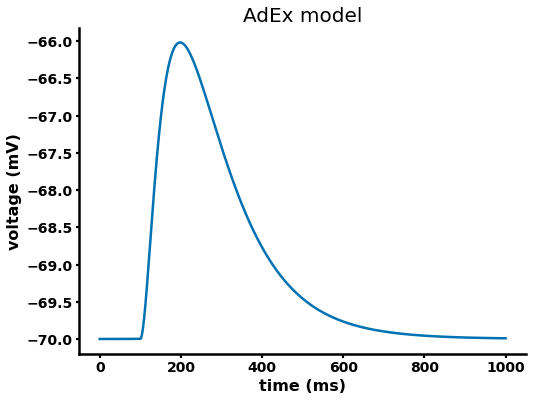

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, V_aEIF)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.title('AdEx model')
plt.show()

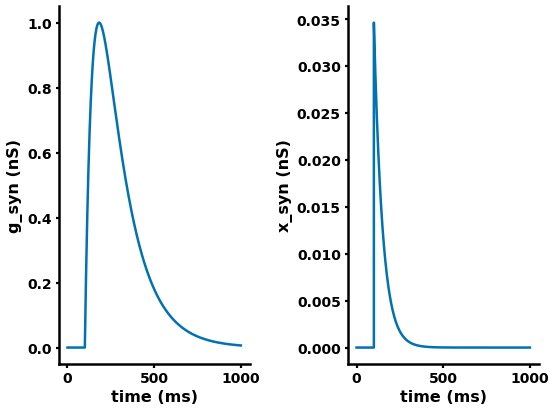

In [11]:
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.plot(t_vec, gsyn)
plt.xlabel('time (ms)')
plt.ylabel('g_syn (nS)')
plt.subplot(1, 2, 2)
plt.plot(t_vec, xsyn)
plt.xlabel('time (ms)')
plt.ylabel('x_syn (nS)')

plt.tight_layout()
plt.show()

In [12]:
np.max(gsyn)

1.0000549362315485

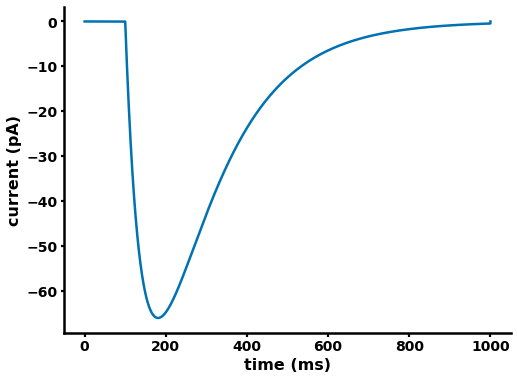

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, Isyn)
plt.xlabel('time (ms)')
plt.ylabel('current (pA)')
plt.show()

In [14]:
tau_rise, tau_decay, x_max = compute_taus(t_vec, Isyn, tstart=100, dt=dt)

print(f"The rise time is: {np.round(tau_rise, 1)} ms")
print(f"The decay time is: {np.round(tau_decay, 1)} ms")

The rise time is: 24.1 ms
The decay time is: 215.2 ms


## Dynamic synapses

# Section 2: Short-term synaptic plasticity


*Estimated timing to here from start of tutorial: 45 min*

Above, we modeled synapses with fixed weights. Now we will explore synapses whose weight change in some input conditions. 

Short-term plasticity (STP) is a phenomenon in which synaptic efficacy changes over time in a way that reflects the history of presynaptic activity. Two types of STP, with opposite effects on synaptic efficacy, have been experimentally observed. They are known as Short-Term Depression (STD) and Short-Term Facilitation (STF).

The mathematical model (_for more information see [here](http://www.scholarpedia.org/article/Short-term_synaptic_plasticity)_) of STP is based on the concept of a limited pool of synaptic resources available for transmission ($R$), such as, for example, the overall amount of synaptic vesicles at the presynaptic terminals. The amount of presynaptic resource changes in a dynamic fashion depending on the recent history of spikes. 

Following a presynaptic spike, (i) the fraction $u$ (release probability) of the available pool to be utilized increases due to spike-induced calcium influx to the presynaptic terminal, after which (ii) $u$ is consumed to increase the post-synaptic conductance. Between spikes, $u$ decays back to zero with time constant $\tau_f$ and $R$ recovers to 1 with time constant $\tau_d$. In summary, the dynamics of excitatory (subscript $E$) STP are given by:

\begin{eqnarray}
&& \frac{du_E}{dt} &=& -\frac{u_E}{\tau_f} + U_0(1-u_E^-)\delta(t-t_{\rm sp}) \\[.5mm]
&& \frac{dR_E}{dt} &=& \frac{1-R_E}{\tau_d} - u_E^+ R_E^- \delta(t-t_{\rm sp}) \qquad (6) \\[.5mm]    
&& \frac{dg_E(t)}{dt} &=& -\frac{g_E}{\tau_E} + \bar{g}_E u_E^+ R_E^- \delta(t-t_{\rm sp})
\end{eqnarray}

where $U_0$ is a constant determining the increment of $u$ produced by a spike. $u_E^-$ and $R_E^-$ denote the corresponding values just before the spike arrives, whereas $u_E^+$ refers to the moment right after the spike. $\bar{g}_E$ denotes the maximum excitatory conductane, and $g_E(t)$ is calculated for all spiketimes $k$, and decays over time with a time constant $\tau_{E}$. Similarly, one can obtain the dynamics of inhibitory STP (i.e., by replacing the subscript $E$ with $I$).

The interplay between the dynamics of $u$ and $R$ determines whether the joint effect of $uR$ is dominated by *depression* or *facilitation*. In the parameter regime of $\tau_d \gg \tau_f$  and for large $U_0$, an initial spike incurs a large drop in $R$ that takes a long time to recover; therefore, the synapse is STD-dominated. In the regime of $\tau_d \ll \tau_f$ and for small $U_0$, the synaptic efficacy is increased gradually by spikes, and consequently, the synapse is STF-dominated. This phenomenological model successfully reproduces the kinetic dynamics of depressed and facilitated synapses observed in many cortical areas.

- for STD, `U0=0.5, tau_d=100., tau_f=50.`

- for STP, `U0=0.2, tau_d=100., tau_f=750.`

In [15]:
# Synaptic parameters
pre_spikes = [100, 150, 200, 250, 300, 350]  # in ms

tau_rise = 2  # rise time in ms
tau_decay = 10  # decay time in ms
g_bar = 1  # maximum conductance in nS
E_syn = 0  # synaptic reversal potential in mV

In [16]:
U0 = 0.2  # synaptic release probability at rest, unitless
tau_d = 100  # synaptic depression time constant of R in ms
tau_f = 750  # synaptic facilitation time constantr of u in ms  

In [17]:
# Voltage (mV)
V_aEIF = np.zeros((len(t_vec), ))
V_aEIF[0] = EL

# Adaptation current (pA)
w = np.zeros((len(t_vec), ))
w[0] = 0

# Synaptic conductance (nS)
gsyn = np.zeros((len(t_vec), ))
gsyn[0] = 0

# Synaptic rise variable (nS)
xsyn = np.zeros((len(t_vec), ))
xsyn[0] = 0

# synaptic release probability (unitless)
u = np.zeros((len(t_vec), ))
u[0] = 0

# Resourses available (a.u.)
R = np.zeros((len(t_vec), ))
R[0] = 1

# Helper variables
tspike = [-1]
flag = True

for n in range(steps):

  # Synapse
  Isyn = gsyn[n]*(V_aEIF[n] - E_syn)
  
  # Membrane
  dV = (-gL*(V_aEIF[n]-EL) + gL*DeltaT*np.exp((V_aEIF[n]-VT)/DeltaT) - w[n] - Isyn)/C
  V_aEIF[n+1] = V_aEIF[n] + dt*dV
  # Adaptation
  dw = (alpha*(V_aEIF[n]-EL) - w[n])/tau_w
  w[n+1] = w[n] + dt*dw
  # Compute du
  du = -u[n]/tau_f
  u[n+1] = u[n] + dt*du
  # Compute dR
  dR = (1.0 - R[n])/tau_d
  R[n+1] = R[n] + dt*dR
  # Compute synaptic variables
  dg = -gsyn[n]/tau_decay + xsyn[n]
  dx = -xsyn[n]/tau_rise
  gsyn[n+1] = gsyn[n] + dt*dg
  xsyn[n+1] = xsyn[n] + dt*dx

  # Spike mechanism
  if V_aEIF[n+1] > Vpeak and flag:
    tspike.append(n*dt)
    V_aEIF[n+1] = Vr
    w[n+1] += b
    flag = False

  # Refractory
  if not flag:
    V_aEIF[n+1] = Vr

  # End of refractory
  if n*dt > tref + tspike[-1]:
    flag = True

  # Presynaptic spike
  if n in [int(j/dt) for j in pre_spikes]:
    u[n+1] += U0*(1.0-u[n])  # calculate the transmission probability
    R[n+1] -= u[n+1]*R[n]  # calculate the available resourses
    xsyn[n+1] += g_bar*normalize(tau_rise, tau_decay)*R[n]*u[n+1]

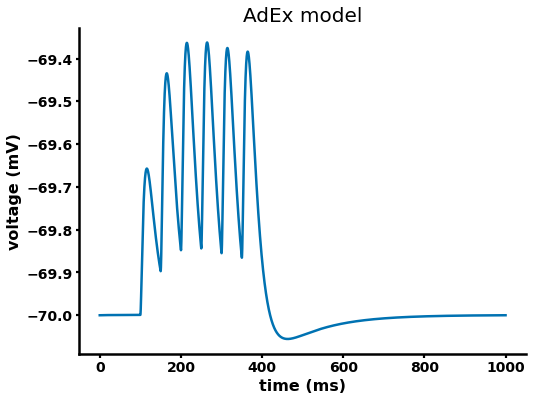

In [18]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, V_aEIF)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.title('AdEx model')
plt.show()

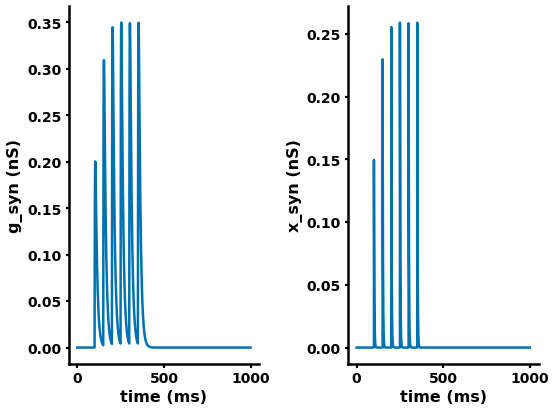

In [19]:
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.plot(t_vec, gsyn)
plt.xlabel('time (ms)')
plt.ylabel('g_syn (nS)')
plt.subplot(1, 2, 2)
plt.plot(t_vec, xsyn)
plt.xlabel('time (ms)')
plt.ylabel('x_syn (nS)')

plt.tight_layout()
plt.show()

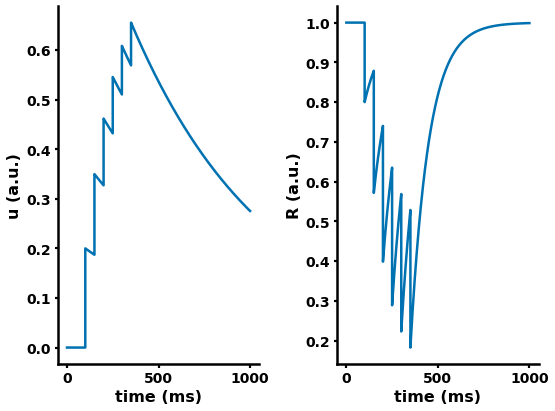

In [20]:
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.plot(t_vec, u)
plt.xlabel('time (ms)')
plt.ylabel('u (a.u.)')
plt.subplot(1, 2, 2)
plt.plot(t_vec, R)
plt.xlabel('time (ms)')
plt.ylabel('R (a.u.)')

plt.tight_layout()
plt.show()

## GABA B receptors



In [21]:
# Simulation parameters
T = 1000  # ms
dt = 0.001  # ms
steps = int(T/dt)
t_vec = np.linspace(0, T, steps+1)

In [22]:
# Parameters
# Synaptic parameters
pre_spikes = [100]  # in ms

g_bar = 1  # maximum conductance in nS
E_syn = -95  # synaptic reversal potential in mV

tauD = 10	 # decay of transmitter concentration ms
K1 = 0.18	 # forward binding rate to receptor (ms-1 mM-1)
K2 = 0.0096  # backward (unbinding) rate of receptor (ms-1)
K3 = 0.19  # rate of G-protein production (ms-1)
K4 = 0.060  # rate of G-protein decay (ms-1)
KD = 17.83  # dissociation constant of the binding of 𝐺 on the K+ channels
nbs	= 1  # number of binding sites of G-protein on K+
f = 0.1  # factor f controlling the G protein dynamics
k1 = 3	 # forward binding rate to transporter (ms-1 mM-1)
k_1	= 0.1  # backward (unbinding) rate of transporter (ms-1)
k2	= 0.02  # clearance of GABA (ms-1)
Bm = 1  # maximum binding capacity of transporter (mM)
Tmax = 1  # max concentration per spike (mM)
gbar = 1  # max conductance (nS)

In [23]:
# Voltage (mV)
V_aEIF = np.zeros((len(t_vec), ))
V_aEIF[0] = EL

# Adaptation current (pA)
w = np.zeros((len(t_vec), ))
w[0] = 0

# Synaptic conductance (nS)
Tvar = np.zeros((len(t_vec), ))
Tvar[0] = 0

# Synaptic rise variable (nS)
Bvar = np.zeros((len(t_vec), ))
Bvar[0] = 0

# synaptic release probability (unitless)
Rvar = np.zeros((len(t_vec), ))
Rvar[0] = 0

# Resourses available (a.u.)
Gvar = np.zeros((len(t_vec), ))
Gvar[0] = 0

Isyn = np.zeros((len(t_vec), ))
# Helper variables
tspike = [-1]
flag = True

for n in range(steps):

  # Synapse
  Isyn[n] = gbar*(Gvar[n]**nbs/(Gvar[n]**nbs+KD))*(V_aEIF[n] - E_syn)
  
  # Membrane
  dV = (-gL*(V_aEIF[n]-EL) + gL*DeltaT*np.exp((V_aEIF[n]-VT)/DeltaT) - w[n] - Isyn[n])/C
  V_aEIF[n+1] = V_aEIF[n] + dt*dV
  # Adaptation
  dw = (alpha*(V_aEIF[n]-EL) - w[n])/tau_w
  w[n+1] = w[n] + dt*dw
  
  # Compute dT
  dT = -Tvar[n]/tauD - k1*Tvar[n]*(Bm - Bvar[n]) + k_1*Bvar[n]
  Tvar[n+1] = Tvar[n] + dt*dT
  # Compute dB
  dB = k1*Tvar[n]*(Bm-Bvar[n]) - (k_1+k2)*Bvar[n]
  Bvar[n+1] = Bvar[n] + dt*dB
  # Compute dR
  dR = K1*Tvar[n]*(1-Rvar[n]) - K2*Rvar[n]
  Rvar[n+1] = Rvar[n] + dt*dR
  # Compute dG
  dG = K3*Rvar[n] - K4*Gvar[n]
  Gvar[n+1] = Gvar[n] + dt*dG

  # Spike mechanism
  if V_aEIF[n+1] > Vpeak and flag:
    tspike.append(n*dt)
    V_aEIF[n+1] = Vr
    w[n+1] += b
    flag = False

  # Refractory
  if not flag:
    V_aEIF[n+1] = Vr

  # End of refractory
  if n*dt > tref + tspike[-1]:
    flag = True

  # Presynaptic spike
  if n in [int(j/dt) for j in pre_spikes]:
    Tvar[n+1] += Tmax

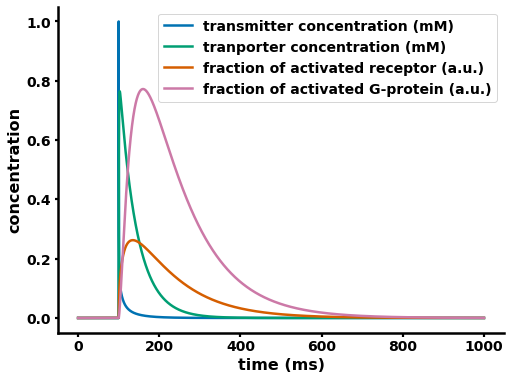

In [24]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, Tvar, label="transmitter concentration (mM)")
plt.plot(t_vec, Bvar, label="tranporter concentration (mM)")
plt.plot(t_vec, Rvar, label="fraction of activated receptor (a.u.)")
plt.plot(t_vec, Gvar, label="fraction of activated G-protein (a.u.)")
plt.xlabel('time (ms)')
plt.ylabel('concentration')
plt.legend()
plt.show()

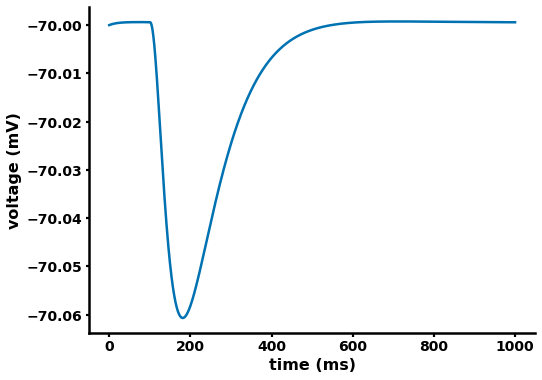

In [25]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, V_aEIF)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.show()

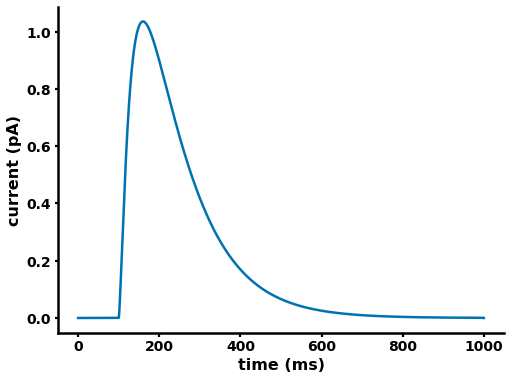

In [26]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, Isyn)
plt.xlabel('time (ms)')
plt.ylabel('current (pA)')
plt.show()

In [27]:
# Calculate the rise and decay time constnats

tau_rise, tau_decay, x_max = compute_taus(t_vec, Isyn, tstart=100, dt=dt)

print(f"The rise time is: {np.round(tau_rise, 1)} ms")
print(f"The decay time is: {np.round(tau_decay, 1)} ms")

The rise time is: 21.4 ms
The decay time is: 150.9 ms


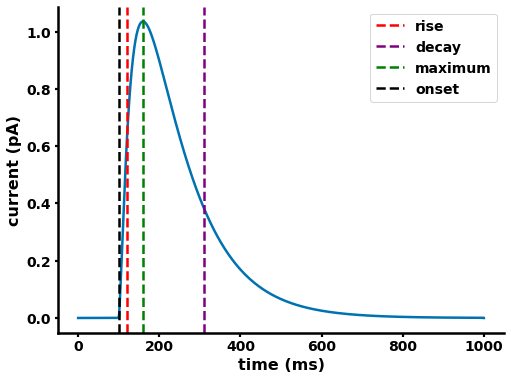

In [28]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, Isyn)
plt.axvline(x=tau_rise+100, linestyle='dashed', color='red', label='rise')
plt.axvline(x=tau_decay+x_max*dt, linestyle='dashed', color='purple', label='decay')
plt.axvline(x=x_max*dt, linestyle='dashed', color='green', label='maximum')
plt.axvline(x=100, linestyle='dashed', color='black', label='onset')
plt.xlabel('time (ms)')
plt.ylabel('current (pA)')
plt.legend()
plt.show()

In [29]:
pre_spikes = [100]  # in ms

gbar = 1/22  # maximum conductance in nS
E_syn = -95  # synaptic reversal potential in mV

In [30]:
# Membrane voltage
V_aEIF = np.zeros((len(t_vec), ))
V_aEIF[0] = EL  # initialization at EL

# Adaptation current
w = np.zeros((len(t_vec), ))
w[0] = 0  # initialization

# synaptic conductance
gsyn = np.zeros((len(t_vec), ))
gsyn[0] = 0  # initialization

# rise variable
xsyn = np.zeros((len(t_vec), ))
xsyn[0] = 0  # initialization

# Synaptic current
Isyn2 = np.zeros((len(t_vec), ))

tspike = [-1]
flag = True

for n in range(steps):

  # Synaptic current
  Isyn2[n] = gsyn[n]*(V_aEIF[n] - E_syn)
  
  # Membrane voltage
  deriv = (-gL*(V_aEIF[n]-EL) + gL*DeltaT*np.exp((V_aEIF[n]-VT)/DeltaT) - w[n] - Isyn2[n])/C
  V_aEIF[n+1] = V_aEIF[n] + dt*deriv
  # Adaptation current
  deriv_w = (alpha*(V_aEIF[n]-EL) - w[n])/tau_w
  w[n+1] = w[n] + dt*deriv_w

  # Synaptic variables
  deriv_g = -gsyn[n]/tau_decay + xsyn[n]
  deriv_x = -xsyn[n]/tau_rise
  gsyn[n+1] = gsyn[n] + dt*deriv_g
  xsyn[n+1] = xsyn[n] + dt*deriv_x

  # Spike mechanism
  if V_aEIF[n+1] > Vpeak and flag:
    tspike.append(n*dt)
    V_aEIF[n+1] = Vr
    w[n+1] += b
    flag = False

  # Refractory
  if not flag:
    V_aEIF[n+1] = Vr

  # End of refractory
  if n*dt > tref + tspike[-1]:
    flag = True

  # Presynaptic spike
  if n in [int(j/dt) for j in pre_spikes]:
    xsyn[n+1] += gbar*normalize(tau_rise, tau_decay)

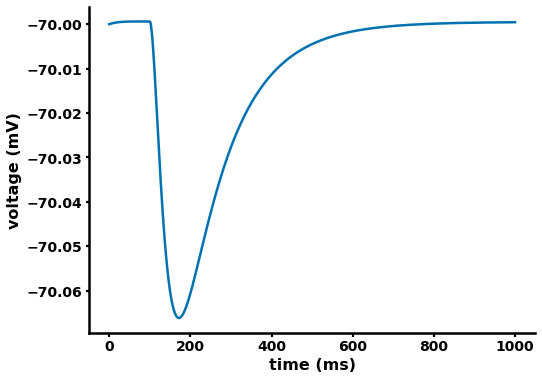

In [31]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, V_aEIF)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.show()

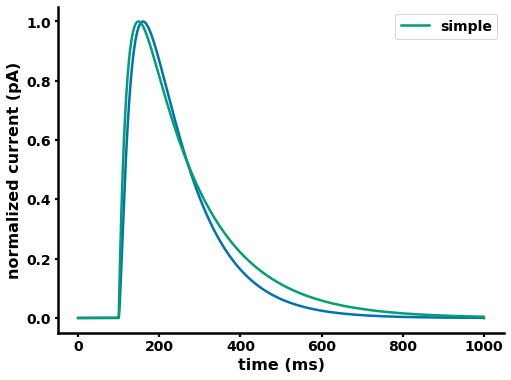

In [32]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, Isyn/np.max(Isyn))
plt.plot(t_vec, Isyn2/np.max(Isyn2), label='simple')
plt.xlabel('time (ms)')
plt.ylabel('normalized current (pA)')
plt.legend()
plt.show()

In [35]:
# Calculate the rise and decay time constnats

tau_rise, tau_decay, x_max = compute_taus(t_vec, Isyn2, tstart=100, dt=dt)

print(f"The rise time is: {np.round(tau_rise, 1)} ms")
print(f"The decay time is: {np.round(tau_decay, 1)} ms")

The rise time is: 14.0 ms
The decay time is: 174.3 ms


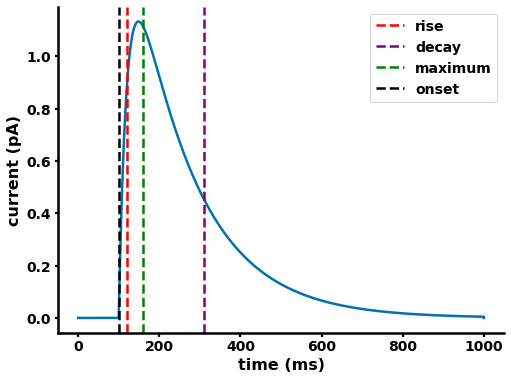

In [34]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, Isyn2)
plt.axvline(x=tau_rise+100, linestyle='dashed', color='red', label='rise')
plt.axvline(x=tau_decay+x_max*dt, linestyle='dashed', color='purple', label='decay')
plt.axvline(x=x_max*dt, linestyle='dashed', color='green', label='maximum')
plt.axvline(x=100, linestyle='dashed', color='black', label='onset')
plt.xlabel('time (ms)')
plt.ylabel('current (pA)')
plt.legend()
plt.show()